In [2]:
from google.colab import files
uploaded=files.upload()

Saving fifa_world_cup_2022_tweets.xlsx to fifa_world_cup_2022_tweets (1).xlsx


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
data=pd.read_excel("fifa_world_cup_2022_tweets.xlsx")
df=pd.DataFrame(data)
df.head(5)

,Index,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive
3,3,2022-11-20 23:58:33+00:00,1,Twitter Web App,Golden Maknae shinning bright\n\nhttps://t.co/...,positive
4,4,2022-11-20 23:58:28+00:00,0,Twitter for Android,"If the BBC cares so much about human rights, h...",negative


In [4]:
df.shape

(22524, 6)

In [5]:
df.columns

Index(['Index', 'Date Created', 'Number of Likes', 'Source of Tweet', 'Tweet',
       'Sentiment'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22524 entries, 0 to 22523
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Index            22524 non-null  int64 
 1   Date Created     22524 non-null  object
 2   Number of Likes  22524 non-null  int64 
 3   Source of Tweet  22524 non-null  object
 4   Tweet            22524 non-null  object
 5   Sentiment        22524 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.0+ MB


In [31]:
def clean_tweet(text):
  text=str(text).lower()
  text=re.sub(r'http\S+|www\S+','',text)
  text=re.sub(r'@\w+', '',text)
  text=re.sub(r'#\w+','',text)
  text=text.encode('ascii','ignore').decode('ascii')
  text=re.sub(r'[^a-z\s]','',text)
  text=re.sub(r'\s+',' ',text).strip()
  return text
text_col='Tweet'
df['clean_text']=df[text_col].apply(clean_tweet)
df=df[df['clean_text'].str.len()>0].reset_index(drop=True)
print(df.shape)

(20670, 8)


In [36]:
print("Before dedup:",df.shape)
df=df.drop_duplicates(subset='clean_text').reset_index(drop=True)
print("After dedup:",df.shape)

Before dedup: (20670, 8)
After dedup: (20670, 8)


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
Vectorizer=TfidfVectorizer(max_features=1000,stop_words='english',min_df=5,max_df=0.8)
X=Vectorizer.fit_transform(df['clean_text'])
print(X.shape)

(20670, 1000)


In [34]:
from sklearn.cluster import KMeans
WCSS=[]
for i in range(2,21):
  km=KMeans(n_clusters=i,init='k-means++',random_state=42)
  km.fit(X)
  labels=km.fit_predict(X)
  WCSS.append(km.inertia_)

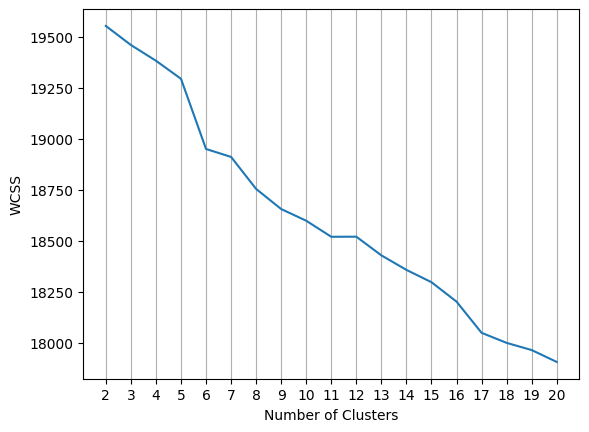

In [35]:
plt.plot([i for i in range(2,21)],WCSS)


plt.xlabel('Number of Clusters')
plt.xticks([i for i in range(2,21)])
plt.ylabel('WCSS')
plt.grid(axis="x")
plt.show()


In [41]:
km=KMeans(n_clusters=6,init='k-means++',random_state=42)
df['cluster']=km.fit_predict(X)
print(df['cluster'].value_counts().sort_index())

cluster
0    14758
1      865
2      845
3      248
4      905
5     3049
Name: count, dtype: int64


In [42]:
feature_names=Vectorizer.get_feature_names_out()
centroids=km.cluster_centers_
K=6
for i in range(K):
  top_indices=centroids[i].argsort()[-10:][::-1]
  top_words=[feature_names[idx] for idx in top_indices]
  count=(df['cluster']==i).sum()
  print(f"clusters{i} (n={count}): {', '.join(top_words)}")

clusters0 (n=14758): qatar, goal, offside, ecuador, var, opening, just, time, match, today
clusters1 (n=865): football, world, qatar, cup, fans, just, time, lets, today, like
clusters2 (n=845): team, qatar, national, cup, world, win, support, ecuador, football, best
clusters3 (n=248): ready, cup, world, getting, im, whos, qatar, team, lets, football
clusters4 (n=905): game, opening, qatar, world, cup, ecuador, vs, win, host, goal
clusters5 (n=3049): world, cup, fifa, opening, qatar, ceremony, live, ecuador, win, today


In [43]:
for i in range(K):
  print(f"\n---Cluster {i} sample tweets---")
  cluster_df=df[df['cluster']==i]
  sample=cluster_df['Tweet'].sample(min(5, len(cluster_df)),random_state=42)
  for t in sample:
    print("-",t[:120])


---Cluster 0 sample tweets---
- @Madders10 On behalf of the people of Iran,I ask you to please use the platform you have in #WorldCup2022 and amplify th
- #WorldCup2022 Live screening @ Sree Chitra Thirunal Park, East fort
#trivandrum 
@ShashiTharoor #thiruvananthapuram
#Qat
- We all can agree that France Giroud &gt;&gt;&gt; France Karim Benzema. #FIFAWorldCup #WorldCup2022 https://t.co/AiJWMEJG
- 31' 0-2 GOAL! Ecuador! Valencia strikes again on a header off a cross into the box #WorldCup #WorldCup2022 #QatarWorldCu
- The best time of the year has started!!!! #WorldCup2022 #FIFAWorldCup #brasilhexa #vamosbrasil @JuanECorral https://t.co

---Cluster 1 sample tweets---
- #Qatar players are going down too easily 
May be they think they would get the whistle easily 

If they let another one 
- It's the start of the FIFA Football #WorldCupâš½ðŸ†

We can't wait to share some of our new sport products &amp; instal
- I donâ€™t think Iâ€™ve ever felt less excited about a World Cup than this o

In [46]:
feature_names=Vectorizer.get_feature_names_out()
centroids=km.cluster_centers_
topic_counts=df['cluster'].value_counts().sort_values(ascending=False)
cluster_labels={
    0:"Genaral World Cup commentary & mixed reaction",
    1:"Perspnal opinions/takes on the tournament",
    2:"Political/social commentary (incl.Iran human rights)",
    3:"Pre match excitement & anticipation",
    4:"Match-specific reactions & fixtures",
    5:"Opening ceremony & tournament kickoff"

}
topic_summary=[]
for cluster_id,count in topic_counts.items():
  top_indices=centroids[cluster_id].argsort()[-8:][::-1]
  top_words=[feature_names[idx] for idx in top_indices]
  topic_summary.append ( {
      'Cluster':cluster_id,
      'Label': cluster_labels.get(cluster_id,"Unlabeled"),
      'Tweet Count': count,
      'Percentage': f"{(count/len(df))*100:.1f}%",
      'Top Keywords': ', '.join(top_words)
  })
summary_df=pd.DataFrame(topic_summary)
print(summary_df.to_string(index=False))

 Cluster                                                Label  Tweet Count Percentage                                              Top Keywords
       0        Genaral World Cup commentary & mixed reaction        14758      71.4%   qatar, goal, offside, ecuador, var, opening, just, time
       5                Opening ceremony & tournament kickoff         3049      14.8% world, cup, fifa, opening, qatar, ceremony, live, ecuador
       4                  Match-specific reactions & fixtures          905       4.4%        game, opening, qatar, world, cup, ecuador, vs, win
       1            Perspnal opinions/takes on the tournament          865       4.2%       football, world, qatar, cup, fans, just, time, lets
       2 Political/social commentary (incl.Iran human rights)          845       4.1%  team, qatar, national, cup, world, win, support, ecuador
       3                  Pre match excitement & anticipation          248       1.2%         ready, cup, world, getting, im, whos, qata

In [50]:
avg_likes_per_cluster=(df.groupby('cluster')['Number of Likes'].agg(['sum','mean','count']).rename(columns={'sum':'Total_Likes','mean':'Avg_Likes','count':'Tweet Count'})).sort_values('Total_Likes',ascending=False)

print(avg_likes_per_cluster)

         Total_Likes   Avg_Likes  Tweet Count
cluster                                      
5             342855  112.448344         3049
0              87589    5.935018        14758
1              26749   30.923699          865
2               6993    8.275740          845
4               2872    3.173481          905
3               2113    8.520161          248


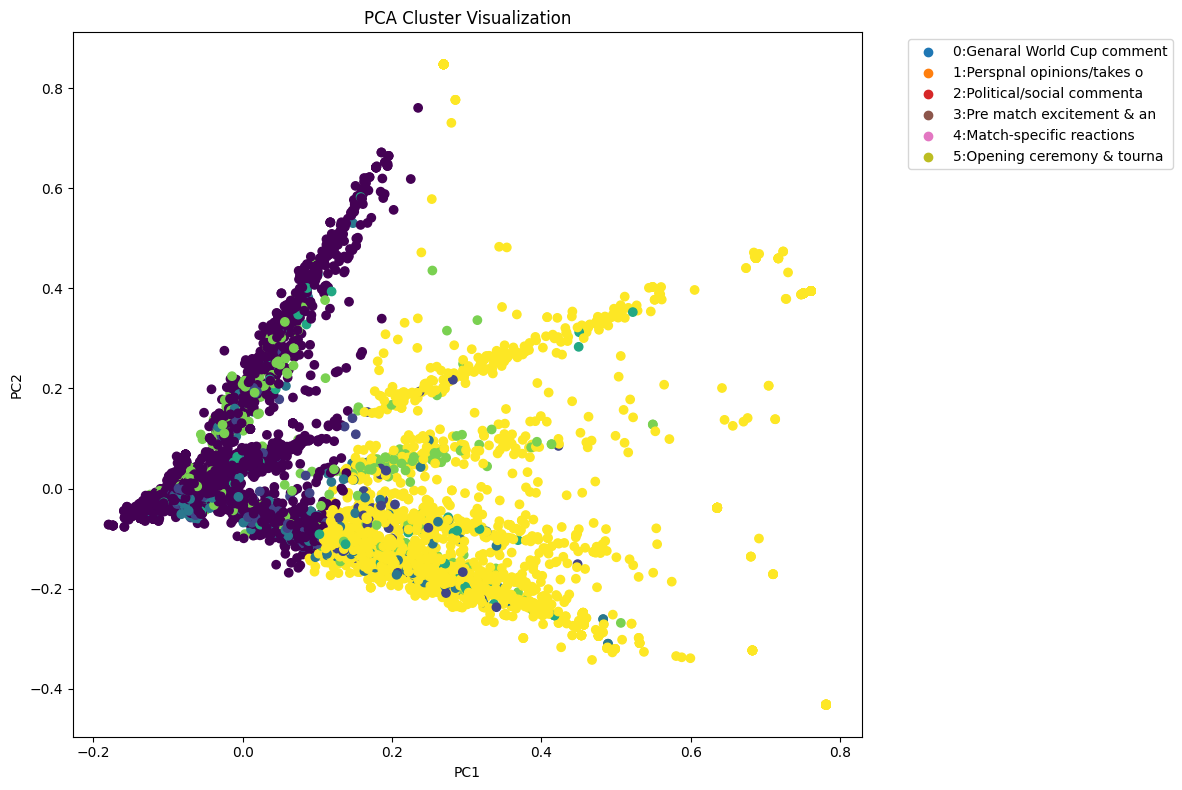

In [54]:
from sklearn.decomposition import PCA
pca= PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X.toarray())
plt.figure(figsize=(12,8))
scatter=plt.scatter(X_pca[:,0],X_pca[:,1],c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Cluster Visualization')
handles=[plt.scatter([],[],color=plt.cm.tab10(i/6),label=f"{i}:{cluster_labels[i][:25]}") for i in range(6)]
plt.legend(handles=handles,bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
print(df['Sentiment'].unique())

['neutral' 'positive' 'negative']


In [57]:
sentiment_breakdown=( df.groupby(['cluster','Sentiment']).size().unstack(fill_value=0))
sentiment_pct=sentiment_breakdown.div(sentiment_breakdown.sum(axis=1),axis=0)*100
sentiment_pct['Label']=sentiment_pct.index.map(cluster_labels)
print(sentiment_pct.round(1).to_string())

Sentiment  negative  neutral  positive                                                 Label
cluster                                                                                     
0              29.1     36.2      34.7         Genaral World Cup commentary & mixed reaction
1              30.9     27.4      41.7             Perspnal opinions/takes on the tournament
2              23.7     34.7      41.7  Political/social commentary (incl.Iran human rights)
3               6.9     22.2      71.0                   Pre match excitement & anticipation
4              29.8     36.0      34.1                   Match-specific reactions & fixtures
5              18.0     41.1      40.9                 Opening ceremony & tournament kickoff


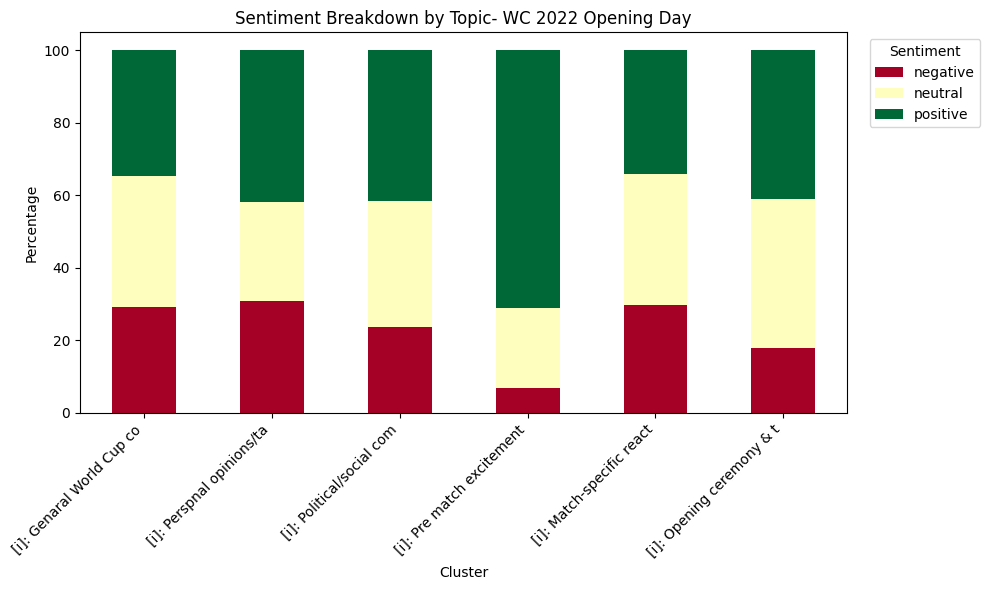

In [61]:
plot_data=sentiment_breakdown.div(sentiment_breakdown.sum(axis=1),axis=0)*100
ax=plot_data.plot(kind="bar",stacked=True,figsize=(10,6),colormap='RdYlGn')
plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.title("Sentiment Breakdown by Topic- WC 2022 Opening Day")
plt.xticks(range(6),[f"[i]: {cluster_labels[i][:20]}" for i in range (6)],rotation=45,ha="right")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()